# ResNet18 Damage Classification

I used post disaster building images from the xBD/xView2 dataset to test different ways of classifying building damage. I worked with four classes: no damage, minor damage, major damage, and destroyed.

I started with a ResNet18 model on a balanced set of 4,000 images. After looking at the results, I noticed that minor and major damage were the two classes the model confused most often. I tried a few changes to the original model and then trained another classifier specifically for minor and major damage. At the end, I combined the two models to see if that could improve the overall result.

The results here are from the balanced subset and validation split I used for these experiments, so they are mainly useful for comparing my own model versions.


## 1. Preparing the data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import os

DATA_ROOT = "/content/drive/MyDrive/Cropped Dataset"
POST_DIR = os.path.join(DATA_ROOT, "train", "post")

manifest = pd.read_csv(os.path.join(DATA_ROOT, "manifest_train.csv"))

classes = ["no-damage", "minor-damage", "major-damage", "destroyed"]

selected_rows = []

for label in classes:
    print("Finding:", label)

    class_df = manifest[manifest["damage_label"] == label].sample(
        frac=1, random_state=42
    )

    found = 0

    for _, row in class_df.iterrows():
        filename = os.path.basename(row["post_crop_path"])
        path = os.path.join(POST_DIR, filename)

        if os.path.exists(path):
            row = row.copy()
            row["actual_post_path"] = path
            selected_rows.append(row)
            found += 1

        if found >= 1000:
            break

    print(label, "found:", found)

small_data = pd.DataFrame(selected_rows)

print("\nTOTAL:", len(small_data))
print(small_data["damage_label"].value_counts())

Finding: no-damage
no-damage found: 1000
Finding: minor-damage
minor-damage found: 1000
Finding: major-damage
major-damage found: 1000
Finding: destroyed
destroyed found: 1000

TOTAL: 4000
damage_label
no-damage       1000
minor-damage    1000
major-damage    1000
destroyed       1000
Name: count, dtype: int64


In [ ]:
import os, shutil
from tqdm.auto import tqdm

LOCAL_DIR = "/content/resnet_data"
os.makedirs(LOCAL_DIR, exist_ok=True)

local_paths = []

for _, row in tqdm(small_data.iterrows(), total=len(small_data)):
    src = row["actual_post_path"]
    dst = os.path.join(LOCAL_DIR, os.path.basename(src))

    if not os.path.exists(dst):
        shutil.copy2(src, dst)

    local_paths.append(dst)

small_data = small_data.copy()
small_data["local_path"] = local_paths

print("Copied:", len(small_data))
print("Local folder:", LOCAL_DIR)

  0%|          | 0/4000 [00:00<?, ?it/s]

Copied: 4000
Local folder: /content/resnet_data


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split

classes = ["no-damage", "minor-damage", "major-damage", "destroyed"]
label_to_idx = {label: i for i, label in enumerate(classes)}

train_df, val_df = train_test_split(
    small_data,
    test_size=0.2,
    random_state=42,
    stratify=small_data["damage_label"]
)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class DamageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["local_path"]).convert("RGB")
        image = self.transform(image)

        label = label_to_idx[row["damage_label"]]

        return image, label

train_dataset = DamageDataset(train_df, train_transform)
val_dataset = DamageDataset(val_df, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

model.fc = torch.nn.Linear(model.fc.in_features, 4)
model = model.to(device)

print("Device:", device)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Device: cuda
Train: 3200
Validation: 800


## 2. First ResNet18 model

I first trained a ResNet18 model using the post disaster images. This gave me a starting point to compare the later experiments with. The best Macro F1 from this version was about **0.706**.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score

# Reinitialize model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, 4)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 5
best_f1 = 0.0
best_epoch = 0

for epoch in range(EPOCHS):

    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu()

            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    val_acc = sum(
        p == y for p, y in zip(all_preds, all_labels)
    ) / len(all_labels)

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Macro F1: {macro_f1:.4f}"
    )

    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/clara_resnet18_best.pth"
        )

        print("  -> Best model saved")

print("\nBest epoch:", best_epoch)
print("Best Macro F1:", round(best_f1, 4))

Epoch 1/5 | Train Acc: 0.5881 | Val Acc: 0.6700 | Macro F1: 0.6707
  -> Best model saved
Epoch 2/5 | Train Acc: 0.7688 | Val Acc: 0.7000 | Macro F1: 0.6995
  -> Best model saved
Epoch 3/5 | Train Acc: 0.8597 | Val Acc: 0.7063 | Macro F1: 0.7037
  -> Best model saved
Epoch 4/5 | Train Acc: 0.9219 | Val Acc: 0.6900 | Macro F1: 0.6918
Epoch 5/5 | Train Acc: 0.9544 | Val Acc: 0.7087 | Macro F1: 0.7059
  -> Best model saved

Best epoch: 5
Best Macro F1: 0.7059


CLASSIFICATION REPORT

              precision    recall  f1-score   support

   no-damage       0.83      0.69      0.75       200
minor-damage       0.57      0.83      0.67       200
major-damage       0.68      0.47      0.56       200
   destroyed       0.84      0.84      0.84       200

    accuracy                           0.71       800
   macro avg       0.73      0.71      0.71       800
weighted avg       0.73      0.71      0.71       800


CONFUSION MATRIX
[[137  40  14   9]
 [  9 166  18   7]
 [ 11  78  95  16]
 [  9   9  13 169]]


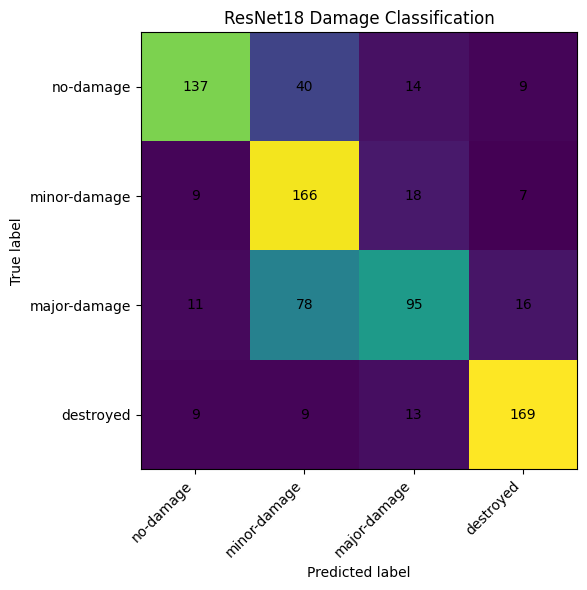

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load the best saved model
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/clara_resnet18_best.pth",
        map_location=device
    )
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

classes = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed"
]

# Classification report
print("CLASSIFICATION REPORT\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=classes
    )
)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print("\nCONFUSION MATRIX")
print(cm)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm)

ax.set_xticks(range(4))
ax.set_yticks(range(4))

ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("ResNet18 Damage Classification")

for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j],
                ha="center",
                va="center")

plt.tight_layout()
plt.show()

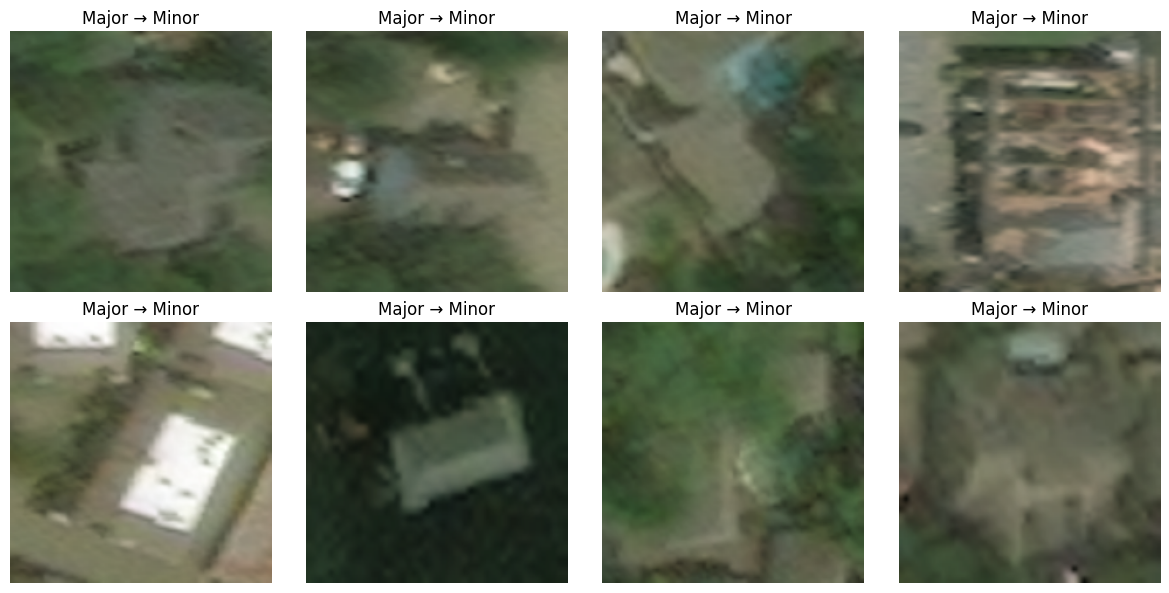

In [ ]:
# Show examples where TRUE = major-damage
# but model predicted minor-damage

import matplotlib.pyplot as plt
import torch

model.eval()

wrong_examples = []

with torch.no_grad():

    for images, labels in val_loader:

        images_gpu = images.to(device)
        outputs = model(images_gpu)
        preds = outputs.argmax(dim=1).cpu()

        for img, true_label, pred_label in zip(
            images, labels, preds
        ):

            # major-damage = 2
            # minor-damage = 1
            if true_label.item() == 2 and pred_label.item() == 1:

                wrong_examples.append(img)

                if len(wrong_examples) >= 8:
                    break

        if len(wrong_examples) >= 8:
            break


fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, img in zip(axes.flatten(), wrong_examples):

    img = img.permute(1, 2, 0)

    # Undo ImageNet normalization
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    ax.imshow(img)
    ax.set_title("Major → Minor")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Trying data augmentation

Next, I added data augmentation during training. This worked better than the first version and increased the best Macro F1 to about **0.742**.


In [ ]:
from torchvision import transforms

aug_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

aug_train_dataset = DamageDataset(
    train_df,
    aug_train_transform
)

aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

print("Augmented training samples:", len(aug_train_dataset))
print("Validation samples:", len(val_dataset))

Augmented training samples: 3200
Validation samples: 800


In [ ]:
aug_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

aug_model.fc = torch.nn.Linear(
    aug_model.fc.in_features,
    4
)

aug_model = aug_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    aug_model.parameters(),
    lr=0.0001
)

print("Augmentation model ready.")

Augmentation model ready.


In [ ]:
from sklearn.metrics import f1_score

EPOCHS = 5

best_aug_f1 = 0.0
best_aug_epoch = 0

for epoch in range(EPOCHS):

    aug_model.train()

    correct = 0
    total = 0

    for images, labels in aug_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = aug_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # validation
    aug_model.eval()

    all_aug_preds = []
    all_aug_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = aug_model(images)
            preds = outputs.argmax(dim=1).cpu()

            all_aug_preds.extend(preds.numpy())
            all_aug_labels.extend(labels.numpy())

    val_acc = sum(
        p == y
        for p, y in zip(all_aug_preds, all_aug_labels)
    ) / len(all_aug_labels)

    macro_f1 = f1_score(
        all_aug_labels,
        all_aug_preds,
        average="macro"
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Macro F1: {macro_f1:.4f}"
    )

    if macro_f1 > best_aug_f1:

        best_aug_f1 = macro_f1
        best_aug_epoch = epoch + 1

        torch.save(
            aug_model.state_dict(),
            "/content/drive/MyDrive/"
            "Clara_ResNet18_Results/"
            "resnet18_augmented_best.pth"
        )

        print("  -> Best augmented model saved")

print("\nBaseline best Macro F1: 0.7059")
print("Augmentation best epoch:", best_aug_epoch)
print("Augmentation best Macro F1:", round(best_aug_f1, 4))

Epoch 1/5 | Train Acc: 0.5541 | Val Acc: 0.6275 | Macro F1: 0.6320
  -> Best augmented model saved
Epoch 2/5 | Train Acc: 0.6744 | Val Acc: 0.7163 | Macro F1: 0.7203
  -> Best augmented model saved
Epoch 3/5 | Train Acc: 0.7241 | Val Acc: 0.7075 | Macro F1: 0.7066
Epoch 4/5 | Train Acc: 0.7734 | Val Acc: 0.6975 | Macro F1: 0.6992
Epoch 5/5 | Train Acc: 0.8175 | Val Acc: 0.7438 | Macro F1: 0.7419
  -> Best augmented model saved

Baseline best Macro F1: 0.7059
Augmentation best epoch: 5
Augmentation best Macro F1: 0.7419


AUGMENTED MODEL CLASSIFICATION REPORT

              precision    recall  f1-score   support

   no-damage       0.78      0.78      0.78       200
minor-damage       0.75      0.56      0.64       200
major-damage       0.61      0.73      0.67       200
   destroyed       0.86      0.90      0.88       200

    accuracy                           0.74       800
   macro avg       0.75      0.74      0.74       800
weighted avg       0.75      0.74      0.74       800

CONFUSION MATRIX
[[155  16  23   6]
 [ 19 113  62   6]
 [ 19  17 147  17]
 [  6   5   9 180]]


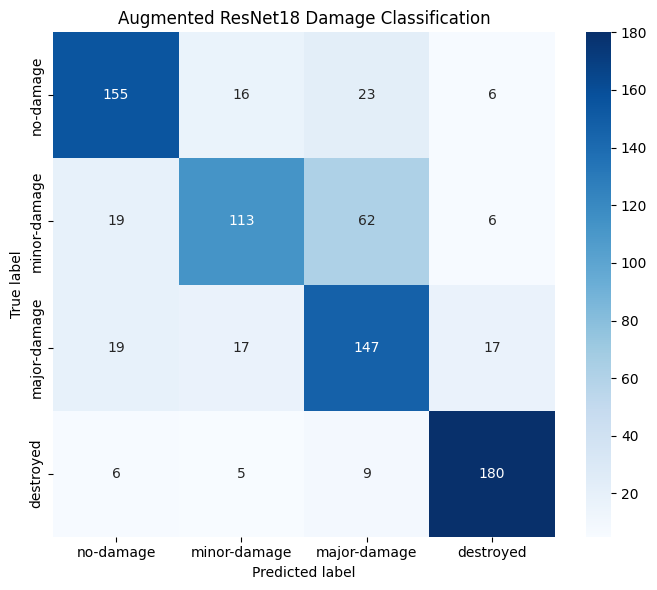

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the BEST augmented model
aug_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Clara_ResNet18_Results/resnet18_augmented_best.pth"
    )
)

aug_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = aug_model(images)
        preds = outputs.argmax(dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("AUGMENTED MODEL CLASSIFICATION REPORT\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=classes
    )
)

cm_aug = confusion_matrix(all_labels, all_preds)

print("CONFUSION MATRIX")
print(cm_aug)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_aug,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Augmented ResNet18 Damage Classification")

plt.tight_layout()
plt.show()

## 4. Other training experiments

I also tried changing the learning rate during training and using focal loss. Neither one performed better than the augmentation model, so I kept the augmentation version for the next step.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

sched_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

sched_model.fc = torch.nn.Linear(
    sched_model.fc.in_features,
    4
)

sched_model = sched_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    sched_model.parameters(),
    lr=0.0001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

print("Scheduler model ready.")

Scheduler model ready.


In [ ]:
from sklearn.metrics import f1_score

EPOCHS = 7

best_sched_f1 = 0.0
best_sched_epoch = 0

for epoch in range(EPOCHS):

    sched_model.train()

    correct = 0
    total = 0

    for images, labels in aug_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = sched_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # Validation
    sched_model.eval()

    sched_preds = []
    sched_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = sched_model(images)
            preds = outputs.argmax(dim=1).cpu()

            sched_preds.extend(preds.numpy())
            sched_labels.extend(labels.numpy())

    val_acc = sum(
        p == y
        for p, y in zip(sched_preds, sched_labels)
    ) / len(sched_labels)

    macro_f1 = f1_score(
        sched_labels,
        sched_preds,
        average="macro"
    )

    # Tell scheduler how validation is doing
    scheduler.step(macro_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Macro F1: {macro_f1:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if macro_f1 > best_sched_f1:

        best_sched_f1 = macro_f1
        best_sched_epoch = epoch + 1

        torch.save(
            sched_model.state_dict(),
            "/content/drive/MyDrive/"
            "Clara_ResNet18_Results/"
            "resnet18_aug_scheduler_best.pth"
        )

        print("  -> Best scheduler model saved")

print("\nAugmentation best Macro F1: 0.7419")
print("Scheduler best epoch:", best_sched_epoch)
print("Scheduler best Macro F1:", round(best_sched_f1, 4))

Epoch 1/7 | Train Acc: 0.5553 | Val Acc: 0.6725 | Macro F1: 0.6701 | LR: 0.000100
  -> Best scheduler model saved
Epoch 2/7 | Train Acc: 0.6759 | Val Acc: 0.7163 | Macro F1: 0.7171 | LR: 0.000100
  -> Best scheduler model saved
Epoch 3/7 | Train Acc: 0.7359 | Val Acc: 0.7125 | Macro F1: 0.7140 | LR: 0.000100
Epoch 4/7 | Train Acc: 0.7834 | Val Acc: 0.7063 | Macro F1: 0.7041 | LR: 0.000050
Epoch 5/7 | Train Acc: 0.8363 | Val Acc: 0.7225 | Macro F1: 0.7218 | LR: 0.000050
  -> Best scheduler model saved
Epoch 6/7 | Train Acc: 0.8656 | Val Acc: 0.7087 | Macro F1: 0.7115 | LR: 0.000050
Epoch 7/7 | Train Acc: 0.8953 | Val Acc: 0.7312 | Macro F1: 0.7315 | LR: 0.000050
  -> Best scheduler model saved

Augmentation best Macro F1: 0.7419
Scheduler best epoch: 7
Scheduler best Macro F1: 0.7315


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        focal_loss = (
            (1 - pt) ** self.gamma
        ) * ce_loss

        return focal_loss.mean()

focal_criterion = FocalLoss(gamma=2.0)

print("Focal Loss ready.")

Focal Loss ready.


In [ ]:
focal_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

focal_model.fc = torch.nn.Linear(
    focal_model.fc.in_features,
    4
)

focal_model = focal_model.to(device)

optimizer = optim.Adam(
    focal_model.parameters(),
    lr=0.0001
)

print("Focal model ready.")

Focal model ready.


In [ ]:
from sklearn.metrics import f1_score

EPOCHS = 5

best_focal_f1 = 0.0
best_focal_epoch = 0

for epoch in range(EPOCHS):

    focal_model.train()

    correct = 0
    total = 0

    for images, labels in aug_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = focal_model(images)

        loss = focal_criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    train_acc = correct / total

    # Validation
    focal_model.eval()

    focal_preds = []
    focal_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = focal_model(images)
            preds = outputs.argmax(dim=1).cpu()

            focal_preds.extend(preds.numpy())
            focal_labels.extend(labels.numpy())

    val_acc = sum(
        p == y
        for p, y in zip(
            focal_preds,
            focal_labels
        )
    ) / len(focal_labels)

    macro_f1 = f1_score(
        focal_labels,
        focal_preds,
        average="macro"
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Macro F1: {macro_f1:.4f}"
    )

    if macro_f1 > best_focal_f1:

        best_focal_f1 = macro_f1
        best_focal_epoch = epoch + 1

        torch.save(
            focal_model.state_dict(),
            "/content/drive/MyDrive/"
            "Clara_ResNet18_Results/"
            "resnet18_aug_focal_best.pth"
        )

        print("  -> Best focal model saved")

print("\n--- MODEL COMPARISON ---")
print("Baseline:              0.7059")
print("Augmentation:          0.7419")
print("Aug + Scheduler:       0.7315")
print("Aug + Focal best:", round(best_focal_f1, 4))
print("Best focal epoch:", best_focal_epoch)

Epoch 1/5 | Train Acc: 0.5572 | Val Acc: 0.6787 | Macro F1: 0.6807
  -> Best focal model saved
Epoch 2/5 | Train Acc: 0.6716 | Val Acc: 0.6488 | Macro F1: 0.6468
Epoch 3/5 | Train Acc: 0.7137 | Val Acc: 0.7175 | Macro F1: 0.7211
  -> Best focal model saved
Epoch 4/5 | Train Acc: 0.7744 | Val Acc: 0.7037 | Macro F1: 0.7021
Epoch 5/5 | Train Acc: 0.7953 | Val Acc: 0.6950 | Macro F1: 0.6902

--- MODEL COMPARISON ---
Baseline:              0.7059
Augmentation:          0.7419
Aug + Scheduler:       0.7315
Aug + Focal best: 0.7211
Best focal epoch: 3


## 5. Looking at minor and major damage

From the confusion matrix, I noticed that minor damage and major damage were still being mixed up pretty often. Because of that, I trained a separate ResNet18 model using only those two classes.


In [ ]:
# Focus on the two hardest classes:
# minor-damage vs major-damage

minor_major_mask = [
    label in [1, 2]
    for label in all_labels
]

mm_labels = [
    label for label, keep
    in zip(all_labels, minor_major_mask)
    if keep
]

mm_preds = [
    pred for pred, keep
    in zip(all_preds, minor_major_mask)
    if keep
]

from sklearn.metrics import confusion_matrix, classification_report

print("MINOR vs MAJOR ANALYSIS\n")

print(
    classification_report(
        mm_labels,
        mm_preds,
        labels=[1, 2],
        target_names=[
            "minor-damage",
            "major-damage"
        ]
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        mm_labels,
        mm_preds,
        labels=[1, 2]
    )
)

MINOR vs MAJOR ANALYSIS

              precision    recall  f1-score   support

minor-damage       0.87      0.56      0.68       200
major-damage       0.70      0.73      0.72       200

   micro avg       0.77      0.65      0.70       400
   macro avg       0.79      0.65      0.70       400
weighted avg       0.79      0.65      0.70       400

Confusion matrix:
[[113  62]
 [ 17 147]]


In [ ]:
# Build Minor vs Major dataset

mm_data = small_data[
    small_data["damage_label"].isin([
        "minor-damage",
        "major-damage"
    ])
].copy()

mm_data["binary_label"] = mm_data["damage_label"].map({
    "minor-damage": 0,
    "major-damage": 1
})

print("Total:", len(mm_data))
print(mm_data["damage_label"].value_counts())

Total: 2000
damage_label
minor-damage    1000
major-damage    1000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

mm_train, mm_val = train_test_split(
    mm_data,
    test_size=0.2,
    random_state=42,
    stratify=mm_data["binary_label"]
)

print("Train:", len(mm_train))
print("Validation:", len(mm_val))

print("\nTrain:")
print(mm_train["damage_label"].value_counts())

print("\nValidation:")
print(mm_val["damage_label"].value_counts())

Train: 1600
Validation: 400

Train:
damage_label
major-damage    800
minor-damage    800
Name: count, dtype: int64

Validation:
damage_label
minor-damage    200
major-damage    200
Name: count, dtype: int64


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim

binary_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

binary_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class MinorMajorDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["local_path"]).convert("RGB")
        image = self.transform(image)

        label = int(row["binary_label"])

        return image, label


mm_train_dataset = MinorMajorDataset(
    mm_train,
    binary_train_transform
)

mm_val_dataset = MinorMajorDataset(
    mm_val,
    binary_val_transform
)

mm_train_loader = DataLoader(
    mm_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

mm_val_loader = DataLoader(
    mm_val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("Train:", len(mm_train_dataset))
print("Validation:", len(mm_val_dataset))

Train: 1600
Validation: 400


In [ ]:
mm_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

mm_model.fc = nn.Linear(
    mm_model.fc.in_features,
    2
)

mm_model = mm_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    mm_model.parameters(),
    lr=0.0001
)

print("Minor vs Major ResNet18 ready.")

Minor vs Major ResNet18 ready.


In [ ]:
# Training output from the saved minor/major specialist experiment.
# The original training-cell source was not present in the uploaded notebook copy.


Epoch 1/5 | Train Acc: 0.6550 | Val Acc: 0.7000 | Macro F1: 0.6936
  -> Best minor-major model saved
Epoch 2/5 | Train Acc: 0.7700 | Val Acc: 0.7400 | Macro F1: 0.7396
  -> Best minor-major model saved
Epoch 3/5 | Train Acc: 0.7913 | Val Acc: 0.7450 | Macro F1: 0.7431
  -> Best minor-major model saved
Epoch 4/5 | Train Acc: 0.8500 | Val Acc: 0.7425 | Macro F1: 0.7420
Epoch 5/5 | Train Acc: 0.8662 | Val Acc: 0.7600 | Macro F1: 0.7598
  -> Best minor-major model saved

Best epoch: 5
Best Minor/Major Macro F1: 0.7598


## 6. Combining the models

For the last experiment, I used the augmentation model first. When it predicted minor damage or major damage, I let the second model check that prediction again. For no damage and destroyed, I kept the first model's prediction.


In [8]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 4-class augmented model
aug_model_final = models.resnet18(weights=None)
aug_model_final.fc = nn.Linear(aug_model_final.fc.in_features, 4)

aug_model_final.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Clara_ResNet18_Results/resnet18_augmented_best.pth",
        map_location=device
    )
)
aug_model_final = aug_model_final.to(device)
aug_model_final.eval()

# minor-major specialist
mm_model_final = models.resnet18(weights=None)
mm_model_final.fc = nn.Linear(mm_model_final.fc.in_features, 2)

mm_model_final.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Clara_ResNet18_Results/minor_major_resnet18_best.pth",
        map_location=device
    )
)
mm_model_final = mm_model_final.to(device)
mm_model_final.eval()

print("Both checkpoints loaded successfully.")

Both checkpoints loaded successfully.


In [11]:
two_stage_preds = []
two_stage_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        # Stage 1: 4-class augmented model
        outputs = aug_model_final(images)
        stage1_preds = outputs.argmax(dim=1)

        final_preds = stage1_preds.clone()

        # Stage 2: only re-check minor/major predictions
        mask = (stage1_preds == 1) | (stage1_preds == 2)

        if mask.any():
            specialist_images = images[mask]

            mm_outputs = mm_model_final(specialist_images)
            mm_preds = mm_outputs.argmax(dim=1)

            # 0 -> minor (class 1)
            # 1 -> major (class 2)
            final_preds[mask] = mm_preds + 1

        two_stage_preds.extend(final_preds.cpu().numpy())
        two_stage_labels.extend(labels.numpy())

# Calculate results
acc = accuracy_score(two_stage_labels, two_stage_preds)
macro_f1 = f1_score(
    two_stage_labels,
    two_stage_preds,
    average="macro"
)

print("TWO-STAGE MODEL RESULTS")
print("Accuracy:", round(acc, 4))
print("Macro F1:", round(macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        two_stage_labels,
        two_stage_preds,
        target_names=[
            "no-damage",
            "minor-damage",
            "major-damage",
            "destroyed"
        ]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(two_stage_labels, two_stage_preds))

TWO-STAGE MODEL RESULTS
Accuracy: 0.775
Macro F1: 0.773

Classification Report:
              precision    recall  f1-score   support

   no-damage       0.78      0.78      0.78       200
minor-damage       0.69      0.80      0.74       200
major-damage       0.78      0.62      0.69       200
   destroyed       0.86      0.90      0.88       200

    accuracy                           0.78       800
   macro avg       0.78      0.78      0.77       800
weighted avg       0.78      0.78      0.77       800


Confusion Matrix:
[[155  22  17   6]
 [ 19 160  15   6]
 [ 19  39 125  17]
 [  6  10   4 180]]


## Results

On my validation subset, the first model had a Macro F1 of about **0.706**, and augmentation improved it to about **0.742**. The separate minor and major classifier reached about **0.760** on its own validation set.

After combining the models, the final accuracy was **0.775** and the Macro F1 was **0.773**. The main reason I tried this approach was that minor and major damage were the classes the original model had the most trouble separating.
